# Introduction

[Sinking of the Titanic](https://en.wikipedia.org/wiki/Sinking_of_the_Titanic)

<font color = 'blue'>
Content: 
    
1. [Load and Check Data](#1)
1. [Exploratory Data Analysis](#2)
    * [Categorical Variables](#3)
       * [Binary(Dichotomous) Variables](#4)
       * [Polytomous Variables](#5)
    * [Numerical Variables](#6)
1. [Some Remarkable Probabilities](#7)
1. [Missing Values and Outliers](#8)
1. [Feature Engineering](#9)
1. [Model](#10)
    * [Simple Logistic Regression](#11)
    * [Comparision of Decision Tree & SVM & KNN & Logistic Regression & XGBoost & Gradient Boost & Ada Boost](#12)
    * [Ensemble Modeling](#13)
1. [Conclusion](#14)
    

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")
#plt.style.available (you can use this code to learn different template of seaborn library, I will use whitegrid)
import plotly.express as px

from collections import Counter

#to close warnings
import warnings
warnings.filterwarnings("ignore")

<a id = '1'></a><br>
# Load and Check Data

In [2]:
train_df = pd.read_csv("../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")
test_PassengerId = test_df["PassengerId"]

In [3]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<a id = '2'></a><br>
# Exploratory Data Analysis

* ## Variable Description

In [4]:
#train_df.columns

1. PassengerId: unique id number to each passenger
1. Survived: passenger survive(1) or died(0)
1. Pclass: passenger ticket class
1. Name: passenger name
1. Sex: gender of passenger
1. Age: age of passenger 
1. SibSp: number of siblings/spouses
1. Parch: number of parents/children 
1. Ticket: ticket number
1. Fare: ticket money as a dolar
1. Cabin: cabin category
1. Embarked: port where passenger embarked(C=Cherbourg, Q=Queenstown, S=Southampton)

In [5]:
#train_df.info()

<a id = '3'></a><br>
### Categorical Variables: 
   * object: Name, Sex, Ticket, Cabin, Embarked
   * float64: Survived
   * int64: Pclass, SibSp, Parch

As you can see clearly, some categorical variables are given integer or float, these are ready for analysis. However, the object ones needs to convert integer type. Before do that, lets look at the categorical variables closely:

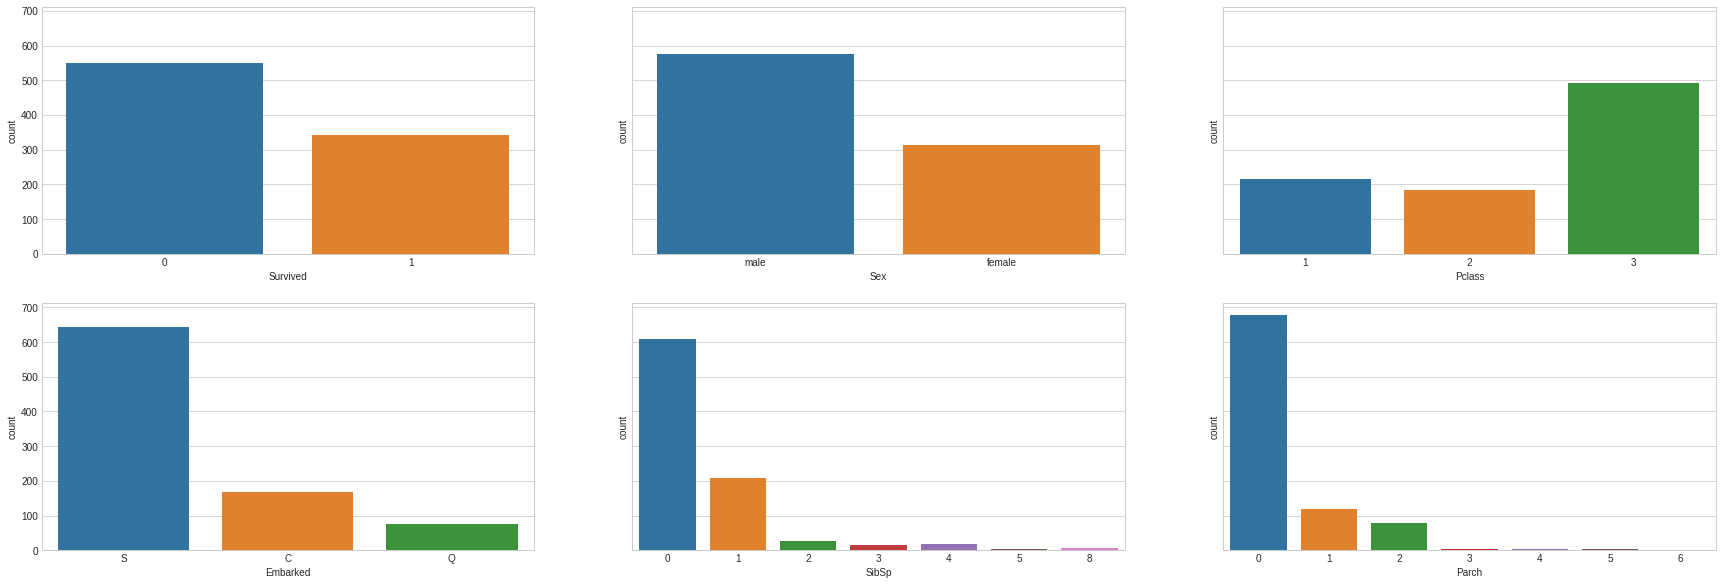

In [6]:
fig, axarr =plt.subplots(2,3, figsize=(30, 10), sharey=True)

sns.countplot(train_df['Survived'], ax=axarr[0][0])
sns.countplot(train_df['Sex'], ax=axarr[0][1])
sns.countplot(train_df['Pclass'], ax=axarr[0][2])
sns.countplot(train_df['Embarked'], ax=axarr[1][0])
sns.countplot(train_df['SibSp'], ax=axarr[1][1])
sns.countplot(train_df['Parch'], ax=axarr[1][2])
fig.show()

<a id = '4'></a><br>
### **Binary(Dichotomous) Variables;** <br> 
These types of variables have just two possible results.<br>

**Survived :** as you can see first graph, the majority of passengers have died. It shows that this is an unbalanced data, zero counts are higher than ones.<br>
**Sex:** This is also an unbalanced data, we can say that passengers are nearly 75% male, 25% female.



<a id = '5'></a><br>
### **Polytomous Variables;** <br> 
Categorical variables with more than two possible values

**Pclass:** As you know, third class is the cheapest class and the number of them is the highest. However, interestingly, the number of sceond class is lower than first class. Personelly, I had expected that first class numbers had minimum.

**Embarked:** As you can see, many people embarked on Southampton port. I wonder if these are that people who have third class ticket. we will examine it later.

**SibSp:** The majortiy of passangers did not have any siblings or spouse in the ship.

**Parch:** like SibSp variable; The majortiy of passangers did not have any parents or children in the ship.

Lastly, we did not plot Name, Ticket and Cabin variables because these have so many categories, we will use these in analysis differently.

<a id = '6'></a><br>
### Numerical Variables:
  * float64: PassengerId, Age, Fare


For numerical variables, firstly I wonder distrubution of them, so I will use histogram for it. However, passangerid is unique variable for each passenger, I will not use this variable, this is just important to show our predicted values for Submission, so we can forget it for now.

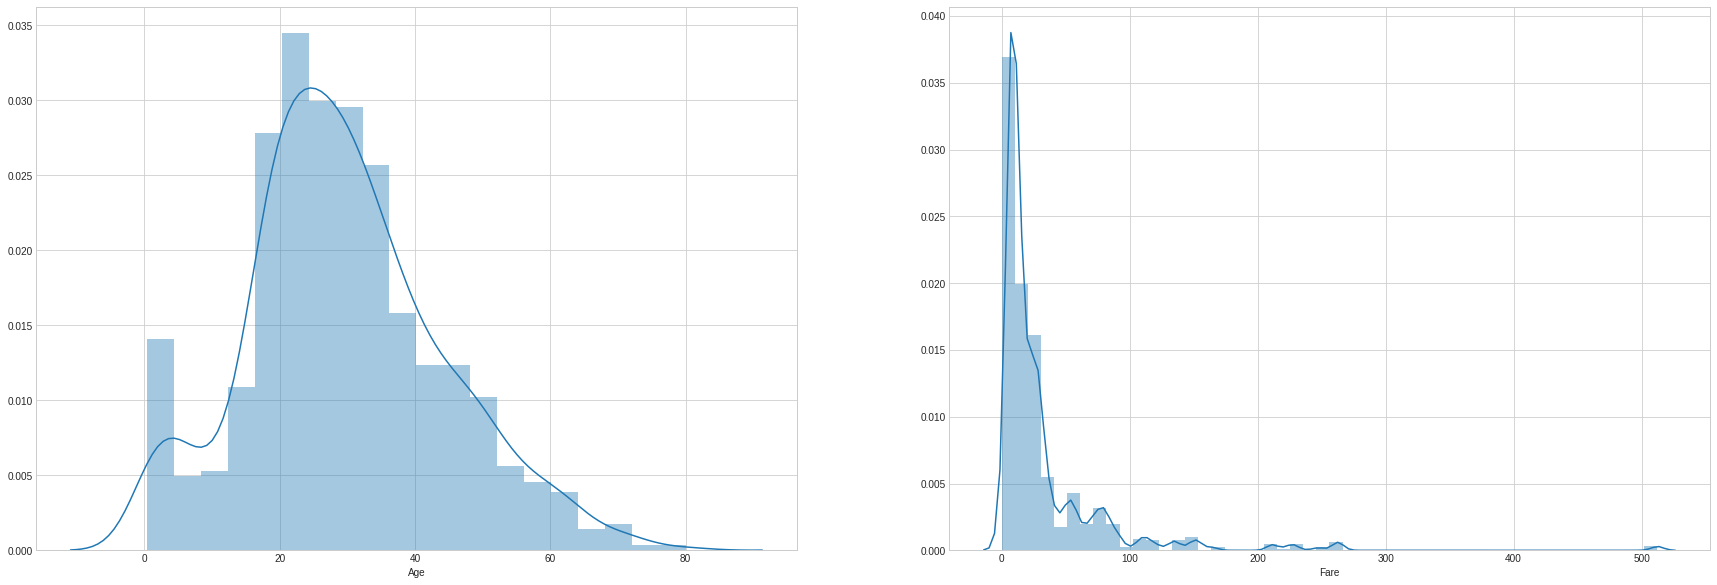

In [7]:
fig, ax =plt.subplots(1,2, figsize=(30, 10), sharey=False)

sns.distplot(train_df['Age'], ax=ax[0])
sns.distplot(train_df['Fare'], ax=ax[1])
fig.show()


**Age:** Age distrubition looks like normal distribution except a youngest age interval.  Generally, it looks like the mean of it is similar to the mod of it and it is about in the 20-40 interval.
**Fare:** These variables have density of the lowest fare value,and it reminds me gamma distribution. 

<a id = '7'></a><br>
# Some Remarkable Probabilities

In [8]:
train_df[['Sex','Survived']].groupby(['Sex'],as_index = False).mean().sort_values(by='Survived',ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [9]:
fig = px.sunburst(train_df, path=['Sex', 'Survived'], values='PassengerId')
fig.show()

As you can see, the survival chance of a woman is higher than a man.

In [10]:
train_df[['Pclass','Survived']].groupby(['Pclass'],as_index = False).mean().sort_values(by='Survived',ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


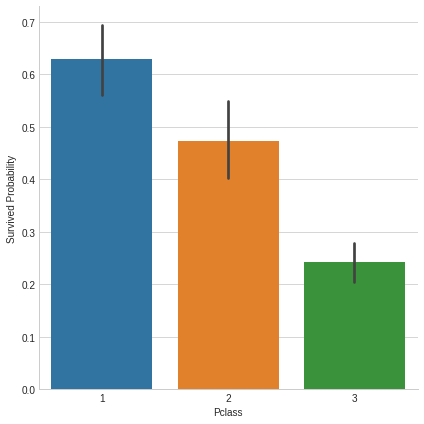

In [11]:
g = sns.factorplot(x = "Pclass", y = "Survived", data = train_df, kind = "bar", size = 6)
g.set_ylabels("Survived Probability")
plt.show()

People who had first class ticket had higher survival probability than the other classes.

In [12]:
train_df[['Embarked','Survived']].groupby(['Embarked'],as_index = False).mean().sort_values(by='Survived',ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


Interestingly, people who embarked Cherbourg port has more chance to survival.

In [13]:
train_df[['SibSp','Survived']].groupby(['SibSp'],as_index = False).mean().sort_values(by='Survived',ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


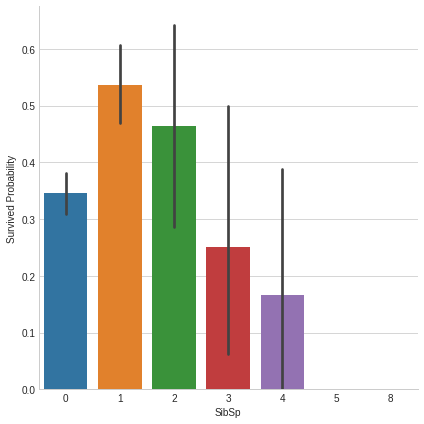

In [14]:
g = sns.factorplot(x = "SibSp", y = "Survived", data = train_df, kind = "bar", size = 6)
g.set_ylabels("Survived Probability")
plt.show()

Passengers who had five or more siblings had died. Having between zero and two SibSp means more survival chance so we can extract a new feature for this.

In [15]:
train_df[['Parch','Survived']].groupby(['Parch'],as_index = False).mean().sort_values(by='Survived',ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


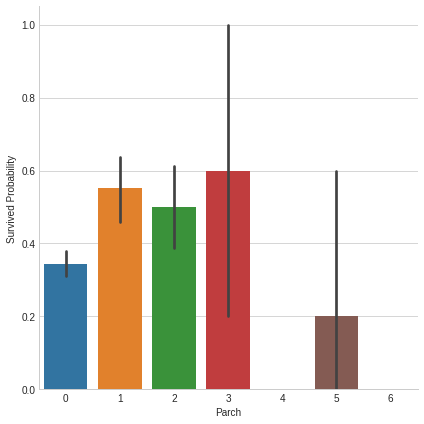

In [16]:
g = sns.factorplot(x = "Parch", y = "Survived", kind = "bar", data = train_df, size = 6)
g.set_ylabels("Survived Probability")
plt.show()

Passengers who had five or more children had died. We can merge Sibsp and Parch and extract new feature with threshold=3. 

In [17]:
#train_df.Age.value_counts(ascending=False, bins=4)
# I use this code try to find right bins number.

In [18]:
bin = [0,10,20,40,60,80] 
#use pd.cut function can attribute the values into its specific bins 
category = pd.cut(train_df.Age,bin) 
category = category.to_frame() 
category.columns = ['AgeRange'] 
#concatenate age and its bin 
df_new = pd.concat([train_df,category],axis = 1) 

In [19]:
df_new[['AgeRange','Survived']].groupby(['AgeRange'],as_index = False).mean()

,AgeRange,Survived
0,"(0, 10]",0.593750
1,"(10, 20]",0.382609
2,"(20, 40]",0.397403
3,"(40, 60]",0.390625
4,"(60, 80]",0.227273


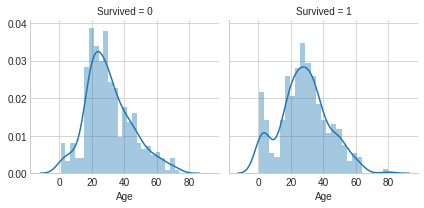

In [20]:
g = sns.FacetGrid(train_df, col = "Survived")
g.map(sns.distplot, "Age", bins = 25)
plt.show()

to find age interval probabilities, I used 'pd.cut' and calculated probabilities of survival. It looks like young age interval has higher chance to survival. we have missing values in age. We can use this distrubution to fill missing values.

In [21]:
train_df.Fare.value_counts(ascending=False, bins=6)
# I use this code try to find right bins number.

(-0.513, 85.388]      825
(85.388, 170.776]      46
(170.776, 256.165]     11
(256.165, 341.553]      6
(426.941, 512.329]      3
(341.553, 426.941]      0
Name: Fare, dtype: int64

In [22]:
bin = [ 0,40,80,170, 255,340,513] 
#use pd.cut function can attribute the values into its specific bins 
category = pd.cut(train_df.Fare,bin) 
category = category.to_frame() 
category.columns = ['FareRange'] 
#concatenate age and its bin 
df_new = pd.concat([train_df,category],axis = 1) 

In [23]:
df_new[['FareRange','Survived']].groupby(['FareRange']).mean()

,Survived
FareRange,
"(0, 40]",0.325714
"(40, 80]",0.549020
"(80, 170]",0.796296
"(170, 255]",0.636364
"(255, 340]",0.666667
"(340, 513]",1.000000


It looks like while care is increasing, survival rate is also increasing but it is just a guess.

Lets look at age distribution according to survived and pclass to see clearly relation.

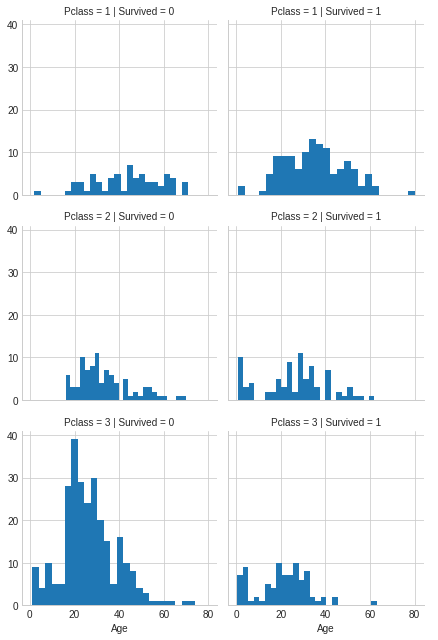

In [24]:
g = sns.FacetGrid(train_df, col = "Survived", row = "Pclass", size = 3)
g.map(plt.hist, "Age", bins = 25)
g.add_legend()
plt.show()

Even if number of passengers in 3 class is higher than others, survival numbers for third class lower than others. It is important information.

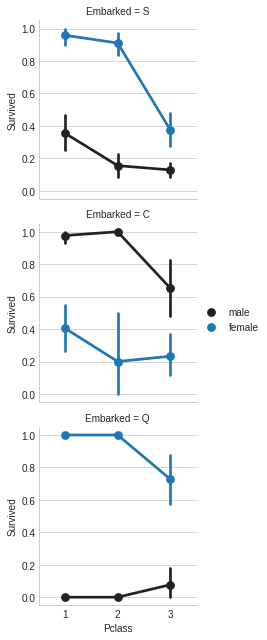

In [25]:
g = sns.FacetGrid(train_df, row = "Embarked", size = 3)
g.map(sns.pointplot, "Pclass","Survived","Sex")
g.add_legend()
plt.show()

Generally,female passengers have higher survival rate than males however males who embarked C port have better survival rate than women.

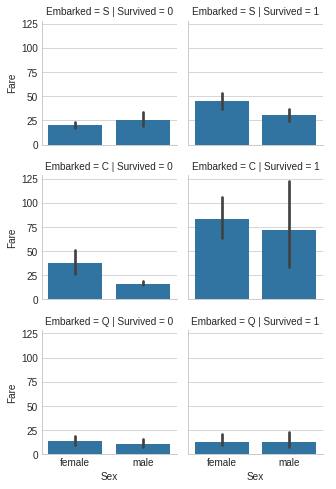

In [26]:
g = sns.FacetGrid(train_df, row = "Embarked", col = "Survived", size = 2.3)
g.map(sns.barplot, "Sex", "Fare")
g.add_legend()
plt.show()

passenger who paid higher fare had higher chance to survive. Fare can be converted to categorical variable to use in analyse.

<a id = '8'></a><br>
# Missing Values and Outliers

## Outliers

In [27]:
#function that finds outliers

def outliers(df,features):
    outlier_indices = []
    
    for c in features:
        # 1st quartile
        Q1 = np.percentile(df[c],25)
        # 3rd quartile
        Q3 = np.percentile(df[c],75)
        # IQR
        IQR = Q3 - Q1
        # Outlier step
        outlier_step = IQR * 1.5
        # detect outlier and their indeces
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        # store indeces
        outlier_indices.extend(outlier_list_col)
    
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2) #to find if sample has 2 or more outliers
    
    return multiple_outliers

In [28]:
#detect outliers
train_df.loc[outliers(train_df,["Age","SibSp","Parch","Fare"])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [29]:
# drop outliers
train_df = train_df.drop(outliers(train_df,["Age","SibSp","Parch","Fare"]),axis = 0).reset_index(drop = True)

we dropped all outliers if it has two or more outliers. we neglected if sample has just one outliers.

## Missing Values

to find all missing values include test data frame we concat test and train data frames:

In [30]:
train_df_len = len(train_df) # not to lose train data set
train_df = pd.concat([train_df,test_df],axis = 0).reset_index(drop = True)

In [31]:
#finding missing values
train_df.columns[train_df.isnull().any()]

Index(['Survived', 'Age', 'Fare', 'Cabin', 'Embarked'], dtype='object')

Because test data no have 'Survived' column, it looks like that it have missing value but actually, there is no missing value in 'Survived' column for train data set.

In [32]:
train_df.isnull().sum() # it shows how many missing values we have each column

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             256
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1007
Embarked          2
dtype: int64

* Age: 256 missing value
* Fare: 1 missing value
* Cabin: 1007 missing value
* Embarked: 2 missing value

we will start with Embarked and Fare because they are little bit easier than others because just have 1 and 2 missing values.

### Embarked and Fare missing values

lets look Embarked and Fare missing values:

In [33]:
train_df[train_df["Embarked"].isnull()] #the rows Embarked has missing values.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
60,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
821,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [34]:
import plotly.express as px

fig = px.box(train_df, x="Embarked", y="Fare",template='plotly_white' )
fig.show()

These two rows have fare of 80 dolar. And, when we look at fare and embarked boxplot, only C port covers 80dolar fare. Even if filling these nan values with 'C' seems to logical, when [I googled ](https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html)the name of passengers, I found that they embarked from Southampton port so I will fill with 'S'.

In [35]:
train_df["Embarked"] = train_df["Embarked"].fillna("S")
train_df[train_df["Embarked"].isnull()] #to check

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


We just have one missing value in Fare. to not change distribution of Fare, fill missing value with median(Because there are some outliers) of it will be good idea. To predict more accuarete, I  will use  third pclass of passengers median age.

In [36]:


fig = px.box(train_df, x="Fare",template='plotly_white' )
fig.show()

In [37]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1033,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [38]:
np.mean(train_df[train_df["Pclass"] == 3])

PassengerId    642.142450
Survived         0.245868
Pclass           3.000000
Age             24.816367
SibSp            0.494302
Parch            0.384615
Fare            12.741220
dtype: float64

In [39]:
train_df["Fare"] = train_df["Fare"].fillna(24.816367)

In [40]:
train_df[train_df["Fare"].isnull()] #to check

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


## Age missing values

In [41]:
train_df[train_df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1.0,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0.0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
27,29,1.0,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
1289,1300,NaN,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
1291,1302,NaN,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
1294,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1297,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


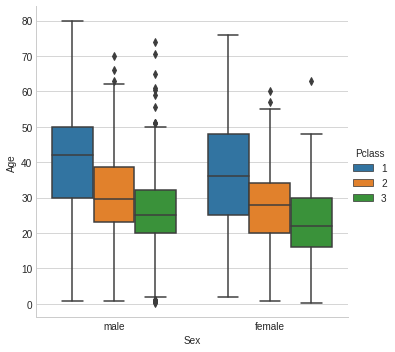

In [42]:
sns.factorplot(x = "Sex", y = "Age", hue = "Pclass",data = train_df, kind = "box")
plt.show()

Age distrubition no show clear pattern to use filling missing values. However, according to classes, each classes have different median age so we can use that to fill missing values. like;
* 1 class:40
* 2 class:30
* 3 class:25

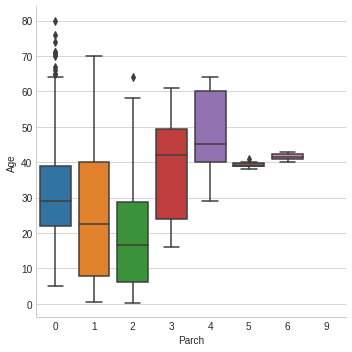

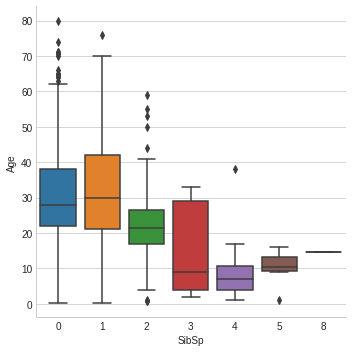

In [43]:
sns.factorplot(x = "Parch", y = "Age", data = train_df, kind = "box")
sns.factorplot(x = "SibSp", y = "Age", data = train_df, kind = "box")
plt.show()

It looks like having zero parent, children or siblings are nearly 25-30 years old. Additionally, having 3 or more children has older age than having 3 or more siblings. People who had one or two parents are younger than people who have one or two siblings or spouse. Lets look at corralation between these variables:


In [44]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
train_df["Sex"] = [1 if i == "male" else 0 for i in train_df["Sex"]] # to convert categorical sex variable to numerical one.

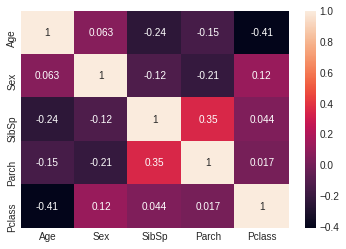

In [46]:
sns.heatmap(train_df[["Age","Sex","SibSp","Parch","Pclass"]].corr(), annot = True)
plt.show()

As you can see, the highest correlation is between age and Pclass, also there is correlation between Parch, Sibsp and Age. however, age and sex correlation is near to zero. we fill age missing values according to this correlation matrix. If we have enough correlation, fill the median age of this category, so on so forth.

In [47]:
index_nan_age = list(train_df["Age"][train_df["Age"].isnull()].index) #make list that inludes all mising values in age column 
for i in index_nan_age: # lets fill these values under the below conditions
    age_pred = train_df["Age"][((train_df["SibSp"] == train_df.iloc[i]["SibSp"]) &(train_df["Parch"] == train_df.iloc[i]["Parch"])& (train_df["Pclass"] == train_df.iloc[i]["Pclass"]))].median()#fill same median with Parch,Pclass and SibSp variables are same
    age_med = train_df["Age"].median()# if not find any same variable, use age median
    if not np.isnan(age_pred):
        train_df["Age"].iloc[i] = age_pred
    else:
        train_df["Age"].iloc[i] = age_med

Note that we use median variables to fill missing values because there are some outliers have, and we donot want mean affect our data distribution.

## Cabin Missing Values

Firstly looking at some information in [google](https://www.encyclopedia-titanica.org/cabins.html), this web site examine all cabin codes detailly and I realized that filling cabin information is very challenging, no enough information about that, lets dive in !

In [48]:
train_df['CabinN'] = train_df['Cabin'].str[:1] #first I extracted first letter of Cabin

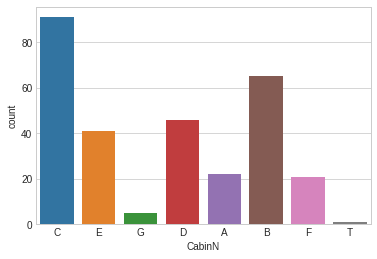

In [49]:
f = sns.countplot(x="CabinN", data = train_df)
plt.show()

Cabin has no show remarkable change with other variables, However we know that A, B, C and T are belong to first class. To simplize it, I changed all missing value as 'M', all A,B,C as ABC, and D, E as 'DE' and F, G as 'FG'.So I added one more feature in my analysis.

In [50]:
train_df['Deck'] = train_df['CabinN']
train_df['Deck'] = train_df['Deck'].fillna('M')

In [51]:
train_df['Deck'] = train_df['Deck'].replace(['A', 'B', 'C'], 'ABC')
train_df['Deck'] = train_df['Deck'].replace(['D', 'E'], 'DE')
train_df['Deck'] = train_df['Deck'].replace(['F', 'G'], 'FG')

train_df['Deck'].value_counts()


M      1007
ABC     178
DE       87
FG       26
T         1
Name: Deck, dtype: int64

In [52]:
train_df.drop(['Cabin','CabinN'],axis=1, inplace=True)

In [53]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299 entries, 0 to 1298
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1299 non-null   int64  
 1   Survived     881 non-null    float64
 2   Pclass       1299 non-null   int64  
 3   Name         1299 non-null   object 
 4   Sex          1299 non-null   int64  
 5   Age          1299 non-null   float64
 6   SibSp        1299 non-null   int64  
 7   Parch        1299 non-null   int64  
 8   Ticket       1299 non-null   object 
 9   Fare         1299 non-null   float64
 10  Embarked     1299 non-null   object 
 11  Deck         1299 non-null   object 
dtypes: float64(3), int64(5), object(4)
memory usage: 121.9+ KB


<a id = '9'></a><br>
# Feature Engineering

### Name and Title Relation

In [54]:
train_df["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

As you see, all names have titles like Mr or Mrs, can we extract these titles to look at relations with survival category. So, all titles in the second place after the comma and all have a dot,  let separete according to this order.

In [55]:
# example to understand separation:
#s = " Allen, Mr. William Henry"
#s.split(".") # this separete with dot
#s.split(".")[0] # and choose first one like 'Allen, Mr'
#s.split(".")[0].split(',') # and we separe new object with comma, so we have 'Allen' and ' Mr'
#s.split(".")[0].split(',')[-1] # and we choose last object of it, it is : ' Mr'
#s.split(".")[0].split(',')[-1].strip() # and we use .strip() if we have any space to get rid of it.

In [56]:
name = train_df["Name"]
train_df["Title"] = [i.split(".")[0].split(",")[-1].strip() for i in name]

In [57]:
train_df.Title.value_counts()

Mr              753
Miss            255
Mrs             197
Master           60
Rev               8
Dr                8
Col               4
Mlle              2
Ms                2
Major             2
Dona              1
Mme               1
the Countess      1
Jonkheer          1
Capt              1
Sir               1
Lady              1
Don               1
Name: Title, dtype: int64

We have lots of Mr, Miss, Mrs and Master titles and the others have relatively small numbers. Let categorize them like female titles, male titles, master and others.

In [58]:
train_df["Title"] = train_df["Title"].replace(["Capt","Col","Don","Dr","Major","Rev","Jonkheer","Dona"],"other")
train_df["Title"] = [0 if i == "Master" else 1 if i == "Miss" or i == "Ms" or i == "Mlle" or i == "Mrs" or i == "Lady" or i == "the Countess"  else 2 if i == "Mr" or i == "Sir" else 3 for i in train_df["Title"]]

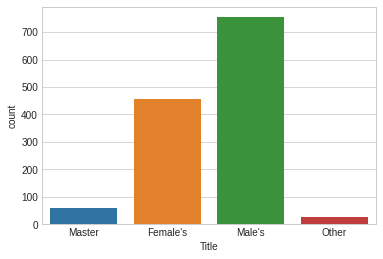

In [59]:
f = sns.countplot(x="Title", data = train_df)
f.set_xticklabels(["Master","Female's","Male's","Other"])

plt.show()

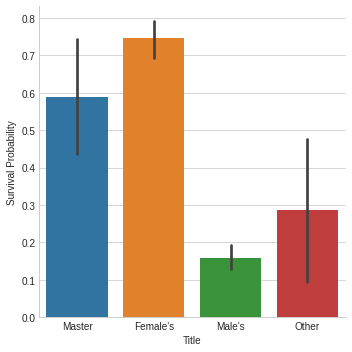

In [60]:
g = sns.factorplot(x = "Title", y = "Survived", data = train_df, kind = "bar")
g.set_xticklabels(["Master","Female's","Male's","Other"])
g.set_ylabels("Survival Probability")
plt.show()

While, the first graph show the number of titles, the second one shows that probabilty of survivals. And clearly seen that, even if male's title so many, the survival rate of it is very low. <br>
we will use title column for analysis so we donot need name column anymore, lets drop it.

In [61]:
train_df.drop(labels = ["Name"], axis = 1, inplace = True)

We set new title column as 1,2,3 and 4 , however actually, these are not show any degree of title, so we have to use this colum with dummies. Lets convert this column with dummies.

In [62]:
train_df = pd.get_dummies(train_df,columns=["Title"])

### Family Size

to sum SibSp and Parch, we can find exact family size, and to count passenger herself/himself, we have to add one.lets do it;

In [63]:
train_df["Fsize"] = train_df["SibSp"] + train_df["Parch"] + 1

we have new column named Fsize, lets look at survival probablities of them;

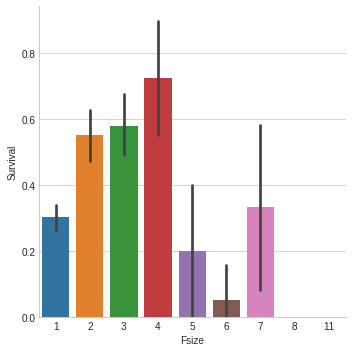

In [64]:
g = sns.factorplot(x = "Fsize", y = "Survived", data = train_df, kind = "bar")
g.set_ylabels("Survival")
plt.show()

After family size reached 4, survival rate decreases dramatically, so we can split this data set in two as high survival probability and low survival probablity and also convert this new column to dummies.

In [65]:
train_df["family_size"] = [1 if i < 5 else 0 for i in train_df["Fsize"]]

In [66]:
train_df = pd.get_dummies(train_df, columns= ["family_size"])

### Embarked

We detailly examined this variable before. We donot extract any new column for it, however because embarked column categorical and doesnot have any degree, we have to convert it dummies.

In [67]:
train_df = pd.get_dummies(train_df, columns=["Embarked"])

### Ticket

In [68]:
train_df["Ticket"].head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

Some ticket numbers have string values, like 'A/5', 'PC', these will be a clue for survival, so lets get these codes and extract new variable;

In [69]:
tickets = [] # new empty list
for i in list(train_df.Ticket): # to look each data in Ticket column
    if not i.isdigit(): # if data is not just a digit number
        tickets.append(i.replace(".","").replace("/","").strip().split(" ")[0])# split with '.' and '/' and drop all space than append the list the first item
    else: # if just a digit number, write 'x'
        tickets.append("x")
train_df["Ticket"] = tickets

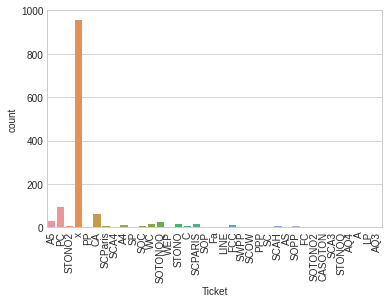

In [70]:
sns.countplot(x="Ticket", data = train_df)
plt.xticks(rotation = 90)
plt.show()

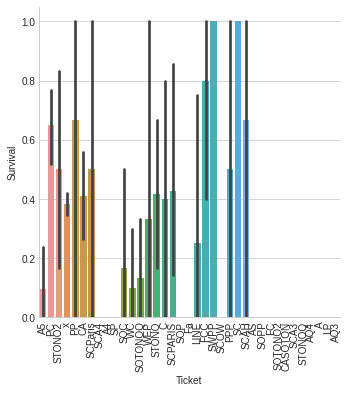

In [71]:
g = sns.factorplot(x = "Ticket", y = "Survived", data = train_df, kind = "bar")
g.set_ylabels("Survival")
plt.xticks(rotation = 90)
plt.show()

Even if there are lots of x value, survival probability of x is not high. Lets convert dummies to this column too;

In [72]:
train_df = pd.get_dummies(train_df, columns= ["Ticket"], prefix = "T")# prefix = 'T' means that each dummy column begins with 'T' not 'Tickets'

> ### Pclass & Sex

We donot do any convertion method for Pclass and Sex features, but These also are had to covert dummies.

In [73]:
train_df["Pclass"] = train_df["Pclass"].astype("category")
train_df = pd.get_dummies(train_df, columns= ["Pclass"])

In [74]:
train_df["Sex"] = train_df["Sex"].astype("category")
train_df = pd.get_dummies(train_df, columns=["Sex"])

### Passenger ID & Cabin

In [75]:
train_df.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,Deck,Title_0,Title_1,Title_2,...,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3,Sex_0,Sex_1
0,1,0.0,22.0,1,0,7.2500,M,0,0,1,...,0,0,0,0,0,0,0,1,0,1
1,2,1.0,38.0,1,0,71.2833,ABC,0,1,0,...,0,0,0,0,0,1,0,0,1,0
2,3,1.0,26.0,0,0,7.9250,M,0,1,0,...,0,0,0,0,0,0,0,1,1,0
3,4,1.0,35.0,1,0,53.1000,ABC,0,1,0,...,0,0,0,0,1,1,0,0,1,0
4,5,0.0,35.0,0,0,8.0500,M,0,0,1,...,0,0,0,0,1,0,0,1,0,1


Passenger ID is unique number for each passenger so it is meanningless for analysis and Cabin has lots of missing value and I can find any logic to fill them. So I will drop them.

In [76]:
train_df = pd.get_dummies(train_df, columns= ["Deck"])

In [77]:
train_df.drop(labels = ["PassengerId"], axis = 1, inplace = True)

### Age

In [78]:

train_df['Infants'] = train_df['Age'].apply(lambda x: 1 if x < 1 else 0)
train_df['Child'] = train_df['Age'].apply(lambda x: 1 if x < 18 else 0)
train_df['Adult'] = train_df['Age'].apply(lambda x: 1 if x >= 18 and x < 65 else 0)
train_df['Elderly'] = train_df['Age'].apply(lambda x: 1 if x >= 65 else 0)
 

<a id = '10'></a><br>
# MODEL

loading libraries that are needed for prediction

In [79]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

### Train Test Split

we concanated train and test before , and we calculate train data frame length. Now, we split again according to this len. And as you remember, our survival column in test dataframe have filled with NaN values because of concanatation.So,  We will drop survival column also.

In [80]:
train_df_len

881

#### Split our test data

In [81]:
test = train_df[train_df_len:]
test.drop(labels = ["Survived"],axis = 1, inplace = True)

####  Model Components
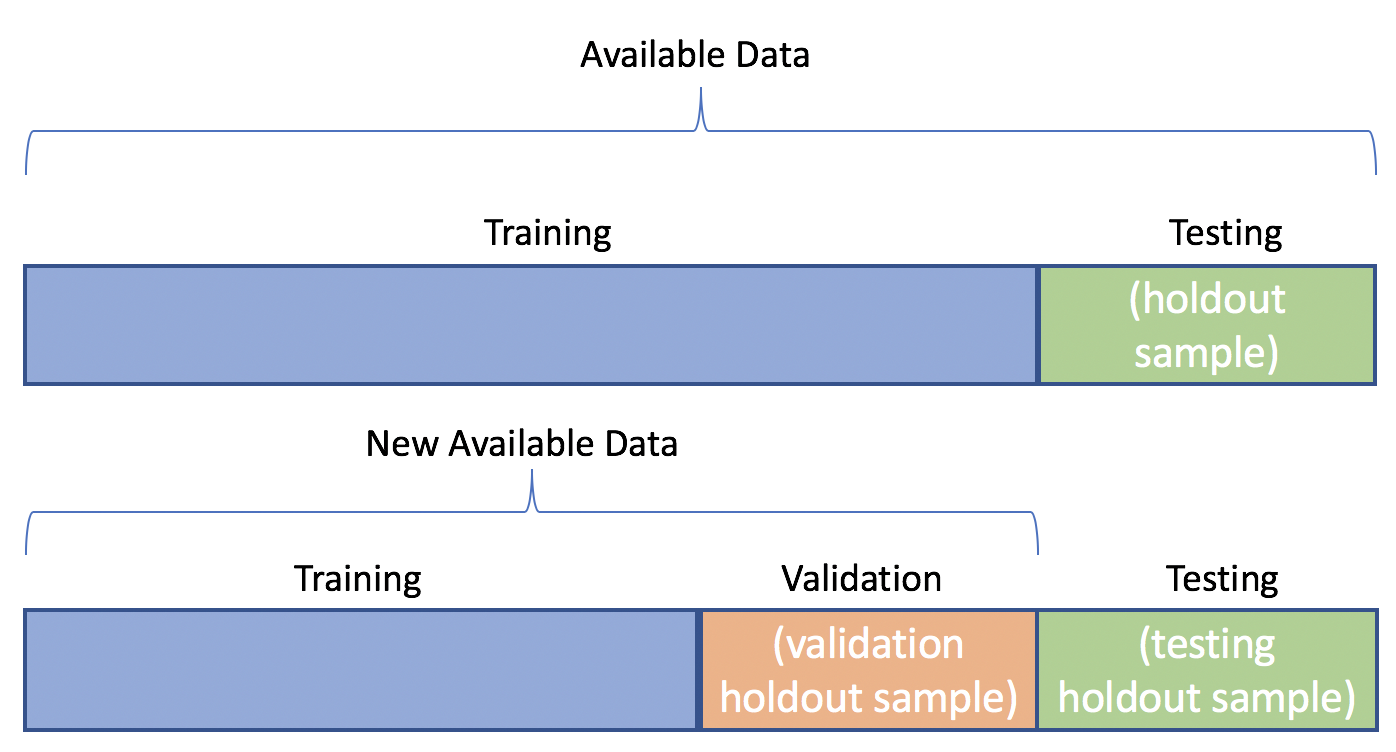

In [82]:
train = train_df[:train_df_len]
X_train = train.drop(labels = "Survived", axis = 1)
y_train = train["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.33, random_state = 42)
print("X_train",len(X_train))
print("X_test",len(X_test))
print("y_train",len(y_train))
print("y_test",len(y_test))
print("test",len(test))

X_train 590
X_test 291
y_train 590
y_test 291
test 418


Our available Data Length(X_train + X_test + test): 590 + 291 + 418=1299 <br>
Testing (test) : 418 <br>
our new available Data(X_train + X_test): 590 + 291=881 <br>
Validation(X_test): 291 <br>

<a id = '11'></a><br>
## Simple Logistic Regression

In [83]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_log_train = round(logreg.score(X_train, y_train)*100,2) #to see percentage of regression score, we multiple 100 and getting two decimal
acc_log_test = round(logreg.score(X_test,y_test)*100,2)
print("Training Accuracy: % {}".format(acc_log_train))
print("Testing Accuracy: % {}".format(acc_log_test))

Training Accuracy: % 83.22
Testing Accuracy: % 83.51


<a id = '12'></a><br>
## Comparision of Decision Tree & SVM & KNN & Logistic Regression & XGBoost & Gradient Boost & Ada Boost

we will try to tune **best hyperparameters** with **grid search method**. to evaluate these results, we will use **stratified cross validation**.

In [84]:
random_state = 42 # random state model number, we choose exact number to find same result each of run
#our models;
classifier = [DecisionTreeClassifier(random_state = random_state),
             SVC(random_state = random_state),
             RandomForestClassifier(random_state = random_state),
             LogisticRegression(random_state = random_state),
             KNeighborsClassifier(),
             XGBClassifier(random_state=random_state),
             GradientBoostingClassifier(random_state=random_state),
             AdaBoostClassifier(random_state=random_state)]

# decision tree parameters
dt_param_grid = {"min_samples_split" : range(10,500,20),
                "max_depth": range(1,20,2)}

#support vector classifier parameters
svc_param_grid = {"kernel" : ["rbf"],
                 "gamma": [0.001, 0.01, 0.1, 1],
                 "C": [1,10,50,100,200,300,1000]}

#random forest parameter
rf_param_grid = {"max_features": [1,3,10],
                "min_samples_split":[2,3,10],
                "min_samples_leaf":[1,5,30],
                "bootstrap":[False],
                "n_estimators":[100,600],
                "criterion":["entropy"]}

#logistic regression parameters
logreg_param_grid = {"C":np.logspace(-3,3,7),
                    "penalty": ["l1","l2"]}

#k-nearest neighboor parameters
knn_param_grid = {"n_neighbors": np.linspace(1,19,10, dtype = int).tolist(),
                 "weights": ["uniform","distance"],
                 "metric":["euclidean","manhattan"]}

xgb_param_grid = {"max_depth": range(1,20,2)}

gbc_param_grid = {"n_estimators":[10,30]}

adab_param_grid = {"n_estimators":[10,30]}




classifier_param = [dt_param_grid,
                   svc_param_grid,
                   rf_param_grid,
                   logreg_param_grid,
                   knn_param_grid,
                   xgb_param_grid,
                   gbc_param_grid,
                   adab_param_grid]


In [85]:
cv_result = [] # cross validation result: it will add each result
best_estimators = [] #choosing best results
for i in range(len(classifier)):  #this loop try to choose best results according to above models
    clf = GridSearchCV(classifier[i], param_grid=classifier_param[i], cv = StratifiedKFold(n_splits = 10), scoring = "accuracy", n_jobs = -1,verbose = 1) # verbose show us all results when code is running
    clf.fit(X_train,y_train)
    cv_result.append(clf.best_score_)
    best_estimators.append(clf.best_estimator_)
    print(cv_result[i])

Fitting 10 folds for each of 250 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 2380 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   10.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.8271186440677966
Fitting 10 folds for each of 28 candidates, totalling 280 fits


[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 280 out of 280 | elapsed:    5.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.7864406779661016
Fitting 10 folds for each of 54 candidates, totalling 540 fits


...

0.8169491525423729
Fitting 10 folds for each of 2 candidates, totalling 20 fits


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.8355932203389831
Fitting 10 folds for each of 2 candidates, totalling 20 fits


[Parallel(n_jobs=-1)]: Done  13 out of  20 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    0.5s finished


0.8169491525423729


### Visualize scores

Text(0.5, 1.0, 'Cross Validation Scores')

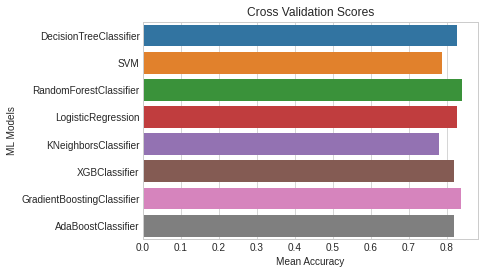

In [86]:
cv_results = pd.DataFrame({"Cross Validation Means":cv_result, "ML Models":["DecisionTreeClassifier", "SVM","RandomForestClassifier",
             "LogisticRegression",
             "KNeighborsClassifier", "XGBClassifier", "GradientBoostingClassifier", "AdaBoostClassifier"]})

g = sns.barplot("Cross Validation Means", "ML Models", data = cv_results)
g.set_xlabel("Mean Accuracy")
g.set_title("Cross Validation Scores")

In [87]:
print(cv_results)

   Cross Validation Means                   ML Models
0                0.827119      DecisionTreeClassifier
1                0.786441                         SVM
2                0.838983      RandomForestClassifier
3                0.827119          LogisticRegression
4                0.779661        KNeighborsClassifier
5                0.816949               XGBClassifier
6                0.835593  GradientBoostingClassifier
7                0.816949          AdaBoostClassifier


We decided to use models that is higher score than 80%.

<a id = '13'></a><br>
# Ensemble Modeling

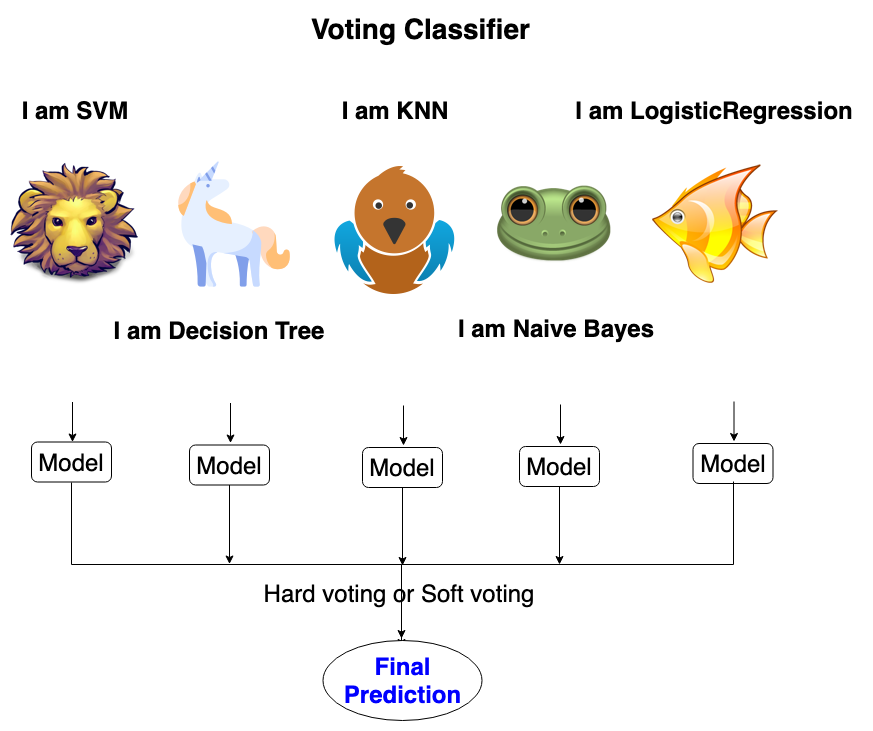

In [88]:
votingC = VotingClassifier(estimators = [("rfc",best_estimators[2]),("gb",best_estimators[6])],voting = "soft", n_jobs = -1)
votingC = votingC.fit(X_train, y_train)
print(accuracy_score(votingC.predict(X_test),y_test))

0.8316151202749141


We use soft voting, because hard voting uses just 'survive or not survive' condition while soft voting uses probability of survive.

<a id = '13'></a><br>
# Conclusion

If you find useful please vote up! , 
Please let me know if you have any questions, comments, or suggestions!

### Prediction and Submission

In [89]:
test_survived = pd.Series(votingC.predict(test), name = "Survived").astype(int)
results = pd.concat([test_PassengerId, test_survived],axis = 1)
results.to_csv("submission.csv", index = False)